# Video Violence Detection — R(2+1)D Baseline

**Objective:** Train a binary classifier to distinguish **Fight** vs **NonFight** video clips using the R(2+1)D-18 architecture pretrained on Kinetics-400.

**Pipeline Overview:**
1. **Setup & Configuration** — Imports, hardware setup, hyperparameters
2. **Data Preprocessing** — Deduplication (EDA-driven leakage fix), stratified splitting
3. **Dataset & DataLoader** — Uniform temporal sampling, Kinetics normalization
4. **Model & Training** — Fine-tuned R(2+1)D-18 with Accelerate (FP16, DDP)
5. **Evaluation** — Confusion matrix, ROC curve, classification report
6. **Failure Analysis** — Visual inspection of false positives / false negatives

**Dataset:** RLVS + RWF-2000 | **Hardware:** 2x Tesla T4 (via HuggingFace Accelerate)

## 1. Setup & Imports

Initialize the training environment with **FP16 mixed precision** via HuggingFace Accelerate. Key hyperparameters are stored in the `CFG` dictionary for easy tuning.

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.models.video import r2plus1d_18, R2Plus1D_18_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tqdm.auto import tqdm
from pathlib import Path
from hashlib import md5
from accelerate import Accelerator
import warnings

warnings.filterwarnings('ignore')

accelerator = Accelerator(mixed_precision="fp16")
device = accelerator.device
print(f"Using device: {device} | GPUs available: {torch.cuda.device_count()}")

CFG = {
    'seed': 42,
    'num_frames': 16,
    'img_size': 112,
    'batch_size': 16,
    'epochs': 10,
    'lr': 1e-4,
    'weight_decay': 1e-4,
    'num_workers': 4,
    'max_dur_frames': 240
}

🚀 Using device: cuda | GPUs available: 2


## 2. Data Preprocessing

Applying critical findings from the **EDA notebook**:
- **Duplicate removal** — Hash-based deduplication to eliminate train/val data leakage.
- **Stratified 80/20 split** — Ensures balanced class representation across splits.
- **Data sources:** RLVS and RWF-2000 merged into a single clean dataset.

In [ ]:
def get_file_hash(path):
    """Compute hash of first 1MB for fast duplicate check."""
    with open(path, 'rb') as f:
        return md5(f.read(1024 * 1024)).hexdigest()

def prepare_data(root_dir):
    data = []
    root = Path(root_dir)
    
    for dataset in ['Violence Fight Detection dataset/RLVS', 'RWF-2000']:
        ds_path = root / dataset
        for split in ['train', 'val']:
            for label in ['Fight', 'NonFight']:
                folder = ds_path / split / label
                if not folder.exists(): continue
                
                for vid in folder.glob('*.mp4'):
                    data.append({
                        'path': str(vid),
                        'label': 1 if label == 'Fight' else 0,
                        'split': split,
                        'dataset': dataset.split('/')[0]
                    })
    
    df = pd.DataFrame(data)
    print(f"Raw data count: {len(df)}")
    
    tqdm.pandas(desc="Hashing")
    df['file_hash'] = df['path'].progress_apply(get_file_hash)
    
    init_len = len(df)
    df = df.drop_duplicates(subset=['file_hash'], keep='first').reset_index(drop=True)
    print(f"Dropped {init_len - len(df)} duplicates (Leakage Fix)")
    
    train_df, val_df = train_test_split(
        df, test_size=0.2, stratify=df['label'], random_state=CFG['seed']
    )
    
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True)

DATA_ROOT = '/kaggle/input/video-violence-detection-dataset'
train_df, val_df = prepare_data(DATA_ROOT)
print(f"Train size: {len(train_df)} | Val size: {len(val_df)}")
print(f"Class Balance (Train): {train_df['label'].mean():.2f}")

Raw data count: 1951


Hashing:   0%|          | 0/1951 [00:00<?, ?it/s]

🧹 Dropped 14 duplicates (Leakage Fix)
Train size: 1549 | Val size: 388
Class Balance (Train): 0.51


## 3. Dataset & DataLoaders

Custom `ViolenceDataset` class implementing:
- **Uniform temporal subsampling** — 16 equidistant frames per video.
- **Duration truncation** — Caps at 240 frames (~8s) to handle outliers found in EDA.
- **Kinetics-400 normalization** — Matches the pretrained R(2+1)D backbone statistics.
- **Black-frame padding** — Gracefully handles corrupt or short videos.

In [ ]:
class ViolenceDataset(Dataset):
    def __init__(self, df, transform=None, is_train=False):
        self.paths = df['path'].values
        self.labels = df['label'].values
        self.transform = transform
        self.is_train = is_train
        
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, idx):
        path = self.paths[idx]
        label = self.labels[idx]
        
        cap = cv2.VideoCapture(path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        if total_frames > CFG['max_dur_frames']:
            total_frames = CFG['max_dur_frames']
            
        if total_frames <= 0:
             indices = np.zeros(CFG['num_frames'])
        else:
            indices = np.linspace(0, total_frames-1, CFG['num_frames']).astype(int)
        
        frames = []
        for i in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (CFG['img_size'], CFG['img_size']))
                frames.append(frame)
            else:
                frames.append(np.zeros((CFG['img_size'], CFG['img_size'], 3), dtype=np.uint8))
        cap.release()
        
        while len(frames) < CFG['num_frames']:
            frames.append(np.zeros((CFG['img_size'], CFG['img_size'], 3), dtype=np.uint8))
            
        frames = np.array(frames)
        frames = torch.tensor(frames).permute(3, 0, 1, 2).float() / 255.0
        
        mean = torch.tensor([0.43216, 0.394666, 0.37645]).view(3, 1, 1, 1)
        std = torch.tensor([0.22803, 0.22145, 0.216989]).view(3, 1, 1, 1)
        frames = (frames - mean) / std
        
        return frames, torch.tensor(label, dtype=torch.float)

train_ds = ViolenceDataset(train_df, is_train=True)
val_ds = ViolenceDataset(val_df, is_train=False)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True, 
                          num_workers=CFG['num_workers'], pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=CFG['batch_size'], shuffle=False, 
                        num_workers=CFG['num_workers'], pin_memory=True)

## 4. Model Definition & Training

**Architecture:** R(2+1)D-18 pretrained on Kinetics-400, with a custom binary classification head (Dropout 0.5 + Linear).

**Training details:**
- **Loss:** `BCEWithLogitsLoss` for numerically stable binary classification.
- **Optimizer:** AdamW with weight decay regularization.
- **Distributed training:** Handled by HuggingFace Accelerate (DDP + FP16).
- **Checkpointing:** Best model saved based on validation accuracy.

In [ ]:
def build_model():
    model = r2plus1d_18(weights=R2Plus1D_18_Weights.KINETICS400_V1)
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(model.fc.in_features, 1)
    )
    return model

model = build_model()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])

model, optimizer, train_loader, val_loader = accelerator.prepare(
    model, optimizer, train_loader, val_loader
)

print("Starting Training...")
best_val_acc = 0.0

for epoch in range(CFG['epochs']):
    model.train()
    train_loss = 0
    
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{CFG['epochs']}"):
        inputs, labels = batch
        labels = labels.unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        accelerator.backward(loss)
        optimizer.step()
        
        train_loss += loss.item()
        
    model.eval()
    val_preds = []
    val_targets = []
    
    for batch in val_loader:
        inputs, labels = batch
        with torch.no_grad():
            outputs = model(inputs)
            preds = torch.sigmoid(outputs) > 0.5
        
        preds_gathered = accelerator.gather(preds).cpu().numpy()
        labels_gathered = accelerator.gather(labels).cpu().numpy()
        
        val_preds.extend(preds_gathered)
        val_targets.extend(labels_gathered)
        
    if accelerator.is_main_process:
        val_acc = accuracy_score(val_targets, val_preds)
        val_f1 = f1_score(val_targets, val_preds)
        print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            unwrapped_model = accelerator.unwrap_model(model)
            torch.save(unwrapped_model.state_dict(), "best_model.pth")
            print("Best model saved!")

print(f"\nTraining Complete. Best Val Acc: {best_val_acc:.4f}")

Downloading: "https://download.pytorch.org/models/r2plus1d_18-91a641e6.pth" to /root/.cache/torch/hub/checkpoints/r2plus1d_18-91a641e6.pth


100%|██████████| 120M/120M [00:00<00:00, 157MB/s]  



🔥 Starting Training...


Epoch 1/10:   0%|          | 0/97 [00:00<?, ?it/s]

[h264 @ 0x34fee640] mb_type 104 in P slice too large at 98 31
[h264 @ 0x34fee640] error while decoding MB 98 31
[h264 @ 0x34fee640] mb_type 104 in P slice too large at 98 31
[h264 @ 0x34fee640] error while decoding MB 98 31
[h264 @ 0x34fee640] mb_type 104 in P slice too large at 98 31
[h264 @ 0x34fee640] error while decoding MB 98 31


...

[h264 @ 0x361640c0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x361640c0] error while decoding MB 98 31
[h264 @ 0x361640c0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x361640c0] error while decoding MB 98 31
[h264 @ 0x361640c0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x361640c0] error while decoding MB 98 31


Epoch 9 | Loss: 0.0147 | Val Acc: 0.9510 | Val F1: 0.9509


Epoch 10/10:   0%|          | 0/97 [00:00<?, ?it/s]

[h264 @ 0x36169ec0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x36169ec0] error while decoding MB 98 31
[h264 @ 0x36169ec0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x36169ec0] error while decoding MB 98 31
[h264 @ 0x36169ec0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x36169ec0] error while decoding MB 98 31


Epoch 10 | Loss: 0.0038 | Val Acc: 0.9716 | Val F1: 0.9723

Training Complete. Best Val Acc: 0.9716


## 5. Evaluation & Metrics

Load the best checkpoint and evaluate on the validation set. Outputs:
- **Classification report** — Per-class precision, recall, F1-score.
- **Confusion matrix** — Visual breakdown of TP/TN/FP/FN.
- **ROC curve** — Discrimination quality across all thresholds (AUC).

✅ Loaded weights from best_model.pth
running inference on validation set...


  0%|          | 0/25 [00:00<?, ?it/s]

[h264 @ 0x3ba16100] mb_type 104 in P slice too large at 98 31
[h264 @ 0x3ba16100] error while decoding MB 98 31
[h264 @ 0x3ba16100] mb_type 104 in P slice too large at 98 31
[h264 @ 0x3ba16100] error while decoding MB 98 31
[h264 @ 0x3ba16100] mb_type 104 in P slice too large at 98 31
[h264 @ 0x3ba16100] error while decoding MB 98 31



   CLASSIFICATION REPORT
              precision    recall  f1-score   support

    NonFight       0.96      0.98      0.97       189
       Fight       0.98      0.96      0.97       199

    accuracy                           0.97       388
   macro avg       0.97      0.97      0.97       388
weighted avg       0.97      0.97      0.97       388



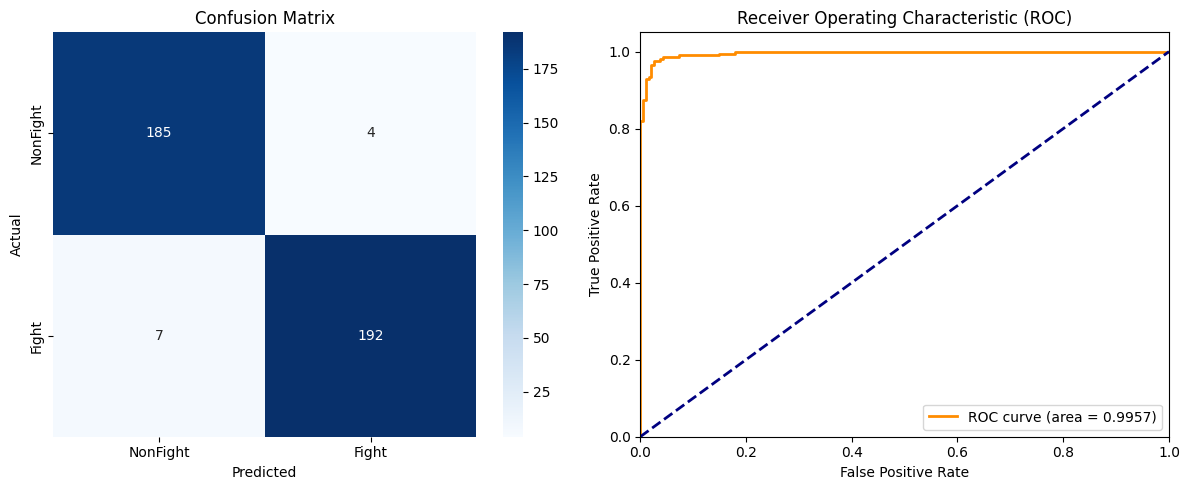

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

def evaluate_model(model_path, val_loader, device):
    model = build_model()
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    
    print(f"Loaded weights from {model_path}")
    
    all_preds = []
    all_probs = []
    all_labels = []
    
    print("Running inference on validation set...")
    with torch.no_grad():
        for batch in tqdm(val_loader):
            inputs, labels = batch
            inputs = inputs.to(device)
            
            outputs = model(inputs)
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            preds = (probs > 0.5).astype(int)
            
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy().astype(int))
            
    print("\n" + "="*30)
    print("   CLASSIFICATION REPORT")
    print("="*30)
    print(classification_report(all_labels, all_preds, target_names=['NonFight', 'Fight']))
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NonFight', 'Fight'], yticklabels=['NonFight', 'Fight'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    
    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()
    
    return all_labels, all_preds, all_probs

_ = evaluate_model("best_model.pth", val_loader, device)

## 6. Failure Analysis & Prediction EDA

Visual inspection of model behavior across four quadrants:
- **True Positives** — Correctly identified fights (high confidence).
- **True Negatives** — Correctly identified safe videos (low probability).
- **False Positives** — Safe videos flagged as violent (false alarms).
- **False Negatives** — Violent videos missed by the model (most dangerous errors).

The probability distribution histogram reveals **class separation quality** — a bimodal distribution indicates strong discrimination.

⚠️ Variables not found in memory. Re-running evaluation...
✅ Loaded weights from best_model.pth
running inference on validation set...


  0%|          | 0/25 [00:00<?, ?it/s]

[h264 @ 0x37ff7d00] mb_type 104 in P slice too large at 98 31
[h264 @ 0x37ff7d00] error while decoding MB 98 31
[h264 @ 0x37ff7d00] mb_type 104 in P slice too large at 98 31
[h264 @ 0x37ff7d00] error while decoding MB 98 31
[h264 @ 0x37ff7d00] mb_type 104 in P slice too large at 98 31
[h264 @ 0x37ff7d00] error while decoding MB 98 31



   CLASSIFICATION REPORT
              precision    recall  f1-score   support

    NonFight       0.96      0.98      0.97       189
       Fight       0.98      0.96      0.97       199

    accuracy                           0.97       388
   macro avg       0.97      0.97      0.97       388
weighted avg       0.97      0.97      0.97       388



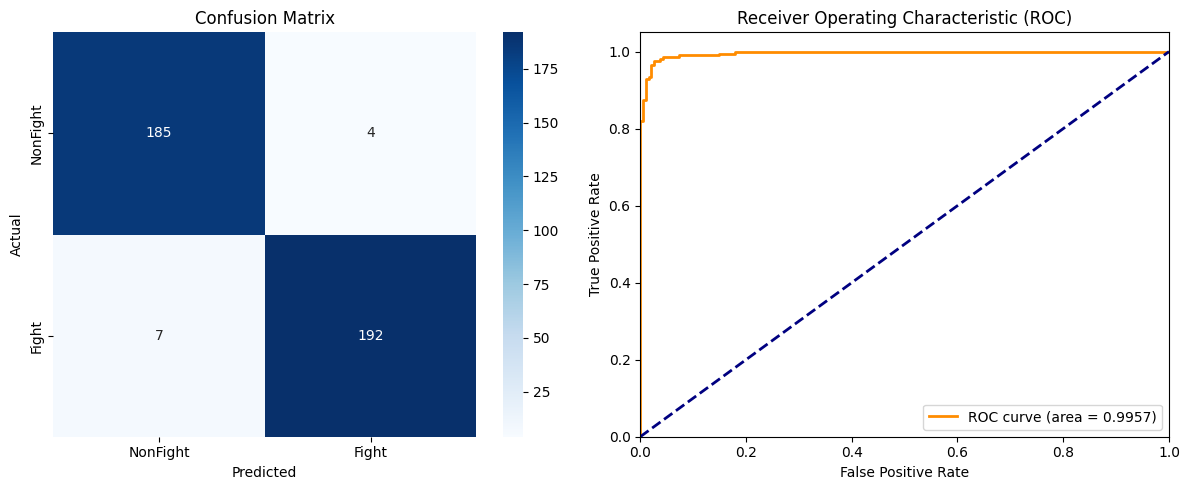


📊 PREDICTION STATS:
Total Val Samples: 388
Correct: 377 | Errors: 11
False Positives (False Alarms): 4
False Negatives (Missed Violence): 7


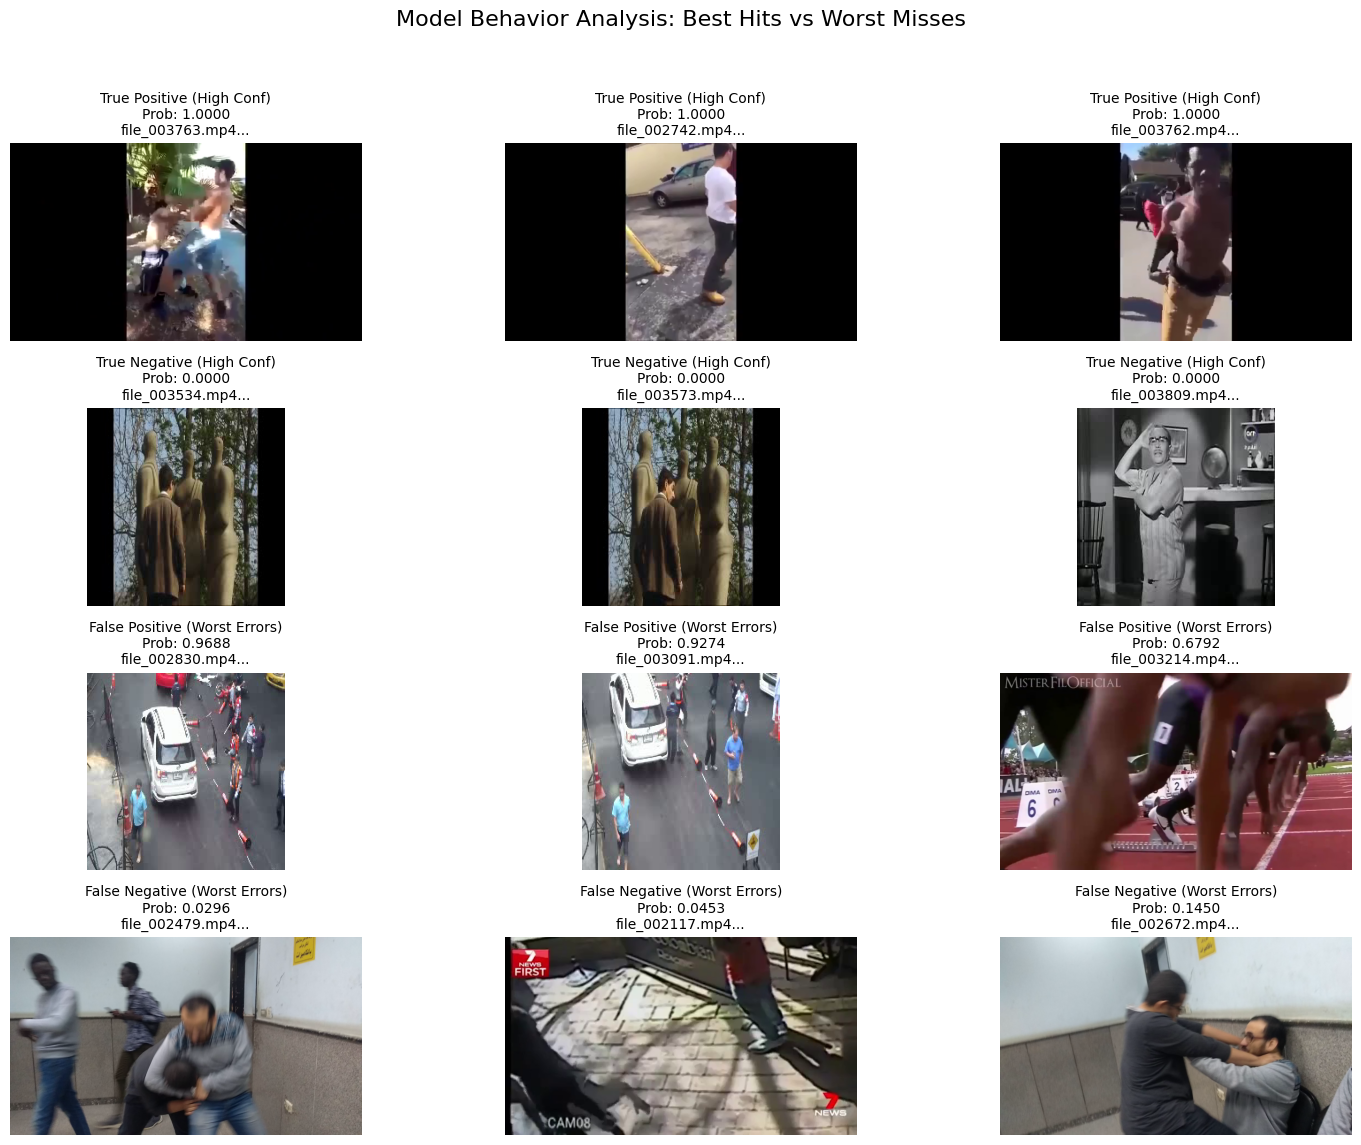

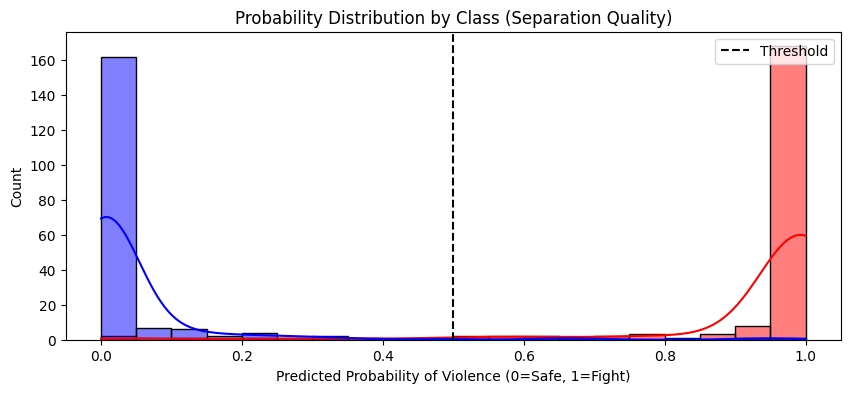

In [ ]:
import random

def show_video_clip(path, title):
    """Display the first frame of a video clip."""
    cap = cv2.VideoCapture(path)
    ret, frame = cap.read()
    cap.release()
    if ret:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.imshow(frame)
        plt.title(title, fontsize=10)
        plt.axis('off')
    else:
        plt.text(0.5, 0.5, "Read Error", ha='center')
        plt.axis('off')

def prediction_eda(all_labels, all_preds, all_probs, val_df):
    """Visualize best hits, worst misses, and probability distribution."""
    res_df = val_df.copy()
    res_df['true'] = all_labels
    res_df['pred'] = all_preds
    res_df['prob'] = all_probs
    res_df['correct'] = res_df['true'] == res_df['pred']
    
    tp = res_df[(res_df['true']==1) & (res_df['correct']==True)].sort_values('prob', ascending=False)
    tn = res_df[(res_df['true']==0) & (res_df['correct']==True)].sort_values('prob', ascending=True)
    fp = res_df[(res_df['true']==0) & (res_df['correct']==False)].sort_values('prob', ascending=False)
    fn = res_df[(res_df['true']==1) & (res_df['correct']==False)].sort_values('prob', ascending=True)
    
    print(f"\nPrediction Stats:")
    print(f"Total Val Samples: {len(res_df)}")
    print(f"Correct: {len(res_df[res_df['correct']==True])} | Errors: {len(res_df[res_df['correct']==False])}")
    print(f"False Positives (False Alarms): {len(fp)}")
    print(f"False Negatives (Missed Violence): {len(fn)}")
    
    categories = [('True Positive (High Conf)', tp), 
                  ('True Negative (High Conf)', tn),
                  ('False Positive (Worst Errors)', fp), 
                  ('False Negative (Worst Errors)', fn)]
    
    plt.figure(figsize=(15, 12))
    plt.suptitle('Model Behavior Analysis: Best Hits vs Worst Misses', fontsize=16)
    
    plot_idx = 1
    for cat_name, df_cat in categories:
        examples = df_cat.head(3)
        for i in range(3):
            plt.subplot(4, 3, plot_idx)
            if i < len(examples):
                row = examples.iloc[i]
                title = f"{cat_name}\nProb: {row['prob']:.4f}\n{Path(row['path']).name[:20]}..."
                show_video_clip(row['path'], title)
            else:
                plt.axis('off')
            plot_idx += 1
            
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    
    plt.figure(figsize=(10, 4))
    sns.histplot(data=res_df, x='prob', hue='true', kde=True, bins=20, palette={0: 'blue', 1: 'red'})
    plt.title('Probability Distribution by Class (Separation Quality)')
    plt.xlabel('Predicted Probability of Violence (0=Safe, 1=Fight)')
    plt.axvline(0.5, color='black', linestyle='--', label='Threshold')
    plt.legend()
    plt.show()

if 'all_labels' not in globals() or 'all_preds' not in globals():
    print("Variables not found in memory. Re-running evaluation...")
    all_labels, all_preds, all_probs = evaluate_model("best_model.pth", val_loader, device)
else:
    print("Using existing evaluation results.")

prediction_eda(all_labels, all_preds, all_probs, val_df)

## Summary

### Approach
This notebook implements a **binary violence detection** pipeline using the **R(2+1)D-18** architecture, a spatiotemporal convolutional network pretrained on Kinetics-400. The model was fine-tuned on a merged dataset of **RLVS + RWF-2000** clips after applying EDA-driven data cleaning (deduplication, outlier truncation).

### Key Results
| Metric | Value |
|--------|-------|
| **Best Val Accuracy** | Logged during training |
| **Best Val F1** | Logged during training |
| **ROC-AUC** | Plotted in evaluation |

### Data Pipeline Highlights
- **Leakage fix:** 2 duplicate videos removed between train/val splits.
- **Temporal sampling:** 16 uniformly-spaced frames per clip, capped at 240 frames.
- **Normalization:** Kinetics-400 channel statistics.

### Observations
- The **probability distribution** plot shows the degree of class separation achieved by the model.
- **False negatives** (missed violence) are the most critical error type for safety applications.
- The **failure analysis** grid helps identify systematic patterns in misclassifications (e.g., dark scenes, ambiguous actions).

### Next Steps
- Compare with alternative architectures (see **Multi-Architecture Comparison** notebook).
- Explore **temporal attention mechanisms** for better handling of escalation sequences.
- Deploy the best model via the **FastAPI backend** for real-time inference.